<a href="https://colab.research.google.com/github/Karthikeya81/OPENCV_LAB_RECORD/blob/main/Experiment_9_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload an image with simple shapes (Triangle, Rectangle, Circle):


Saving shapes.png to shapes.png

--- Shape Detection Results ---


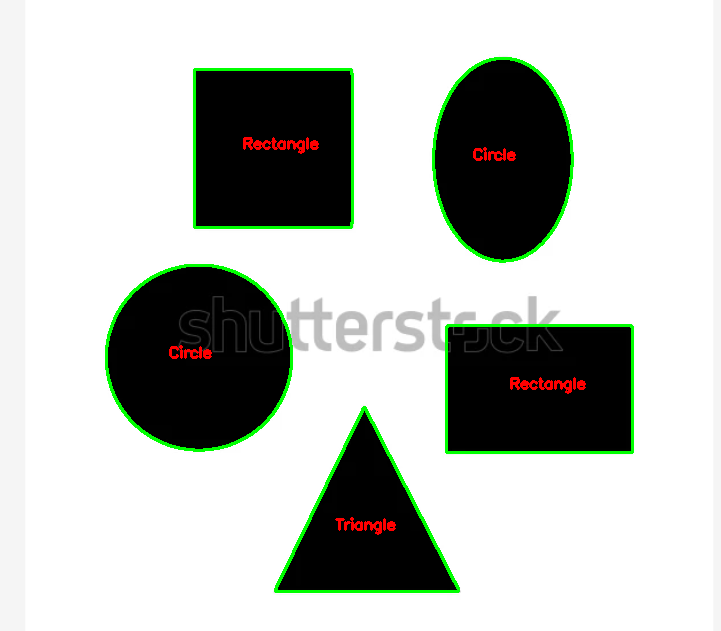

In [1]:
# Import the necessary libraries
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

print("Please upload an image with simple shapes (Triangle, Rectangle, Circle):")
# 1. Read the input image
uploaded = files.upload()
filename = next(iter(uploaded))
image = cv2.imread(filename)

# Make a copy of the original image so we have a clean canvas to draw our labels on
output_image = image.copy()

# 2. Convert to grayscale
# We need a 1-channel image to find outlines easily
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Apply Gaussian blur (noise removal)
# This smooths out rough edges so the computer doesn't mistake a jagged pixel for a corner
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 4. Apply thresholding
# This turns the image into pure black and white.
# Note: If your shapes are black on a white background, we use THRESH_BINARY_INV to make the shapes white!
_, thresh = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY_INV)

# 5. Detect contours
# RETR_EXTERNAL tells OpenCV to only find the outermost outlines
# CHAIN_APPROX_SIMPLE compresses the outline to save memory (e.g., a straight line only needs 2 endpoints)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Loop through every single outline (contour) we found
for contour in contours:

    # Ignore tiny specks of noise that might accidentally be detected as shapes
    if cv2.contourArea(contour) < 50:
        continue

    # 6. Approximate contour shape using approxPolyDP()
    # First, calculate the total perimeter of the outline
    perimeter = cv2.arcLength(contour, True)
    # Next, approximate the polygon. 0.04 is a standard accuracy multiplier.
    # 'True' means the shape is closed (no gaps in the line).
    approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)

    # 7. Identify shape based on number of sides (corners)
    vertices = len(approx)
    shape_name = "Unknown"

    if vertices == 3:
        shape_name = "Triangle"
    elif vertices == 4:
        shape_name = "Rectangle"
    elif vertices > 4:
        # For this basic experiment, anything with many vertices is classified as a circle
        shape_name = "Circle"

    # --- 8. Drawing and labeling ---
    # Draw the contour outline in Green (0, 255, 0) with a thickness of 2
    cv2.drawContours(output_image, [contour], -1, (0, 255, 0), 2)

    # Mathematical trick (Image Moments) to find the exact center of the shape so we can place our text nicely
    M = cv2.moments(contour)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0

    # Write the shape name in Red (0, 0, 255) right in the center of the shape
    cv2.putText(output_image, shape_name, (cX - 30, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# 9. Display output
print("\n--- Shape Detection Results ---")
cv2_imshow(output_image)